# NGP-Net Walkthrough

Demonstrates the currently implemented foundation of the
**Quality-Aware Longitudinal Lung CT Follow-up Assistant**:

```
PNG dataset -> NGP-Net -> growth prediction
```

This notebook: builds the model, loads one real three-timepoint window
from the PNG dataset, runs a forward pass, and visualizes the inputs,
prediction, and deformation field.

**Status caveat:** no checkpoint has been trained yet (see
`docs/reproduction.md`). The model below is randomly initialized, so its
predicted image/mask are structurally correct in shape and pipeline but
**not accurate** -- this notebook demonstrates that the pipeline runs
end-to-end and how to read its outputs, not baseline performance. Re-run
after `scripts/train.py` produces a checkpoint to see real predictions
(see the last cell).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from quality_aware_lung_ct.ngpnet import NGPNet
from quality_aware_lung_ct.ngpnet.config import NGPNetConfig
from quality_aware_lung_ct.data.png.metadata import load_manifest, get_split
from quality_aware_lung_ct.data.png.dataset import PNGDataset
from quality_aware_lung_ct.data.png.transforms import get_transforms
from quality_aware_lung_ct.evaluation.metrics import PSNRMetric, SSIMMetric, DiceMetric

torch.manual_seed(35202)
plt.rcParams["figure.facecolor"] = "white"

## 1. Model

Construct NGP-Net at the paper's defaults. Parameter count is checked
against the published figure (1,984,821) -- see `docs/architecture.md`
for what changed vs. the original author code (packaging only, math
unchanged).

In [2]:
config = NGPNetConfig()
model = NGPNet(img_size=config.in_size, feat_dim=config.feat_dim, depths=config.depths)
model.eval()

n_params = sum(p.nelement() for p in model.parameters())
print(f"NGP-Net parameters: {n_params:,}")
assert n_params == 1_984_821, "parameter count drifted from the paper's figure"

NGP-Net parameters: 1,984,821


## 2. Dataset: one PNG window

Loads a real three-timepoint window (t0, t1, t2) from the PNG manifest.
Falls back to a synthetic window automatically if the dataset isn't
present at `data/external/png` (see `data/README.md`), so this notebook
always runs.

In [3]:
DATA_ROOT = REPO_ROOT / "data" / "external" / "png"

def load_real_sample():
    manifest = load_manifest(DATA_ROOT, config.json_name)
    entries = get_split(manifest, "training")
    transforms = get_transforms(config, is_test=True)
    dataset = PNGDataset(DATA_ROOT, entries, transforms)
    sample = dataset[0]
    *images, mk0, mk1, mk2, month1, month2, info = sample
    im0, im1, im2 = images
    return im0, im1, im2, mk0, mk1, mk2, month1, month2, info


def make_synthetic_sample():
    ''' A blob that grows between t0/t1/t2, standing in for a real window. '''
    rng = np.random.default_rng(35202)
    size = config.in_size
    grid = np.linspace(-1, 1, size)
    zz, yy, xx = np.meshgrid(grid, grid, grid, indexing="ij")
    dist = np.sqrt(zz**2 + yy**2 + xx**2)

    def blob(radius, noise_scale=0.03):
        img = np.exp(-(dist / radius) ** 2).astype(np.float32)
        img += rng.normal(0, noise_scale, size=img.shape).astype(np.float32)
        mask = (dist < radius).astype(np.uint8)
        return torch.from_numpy(img)[None], torch.from_numpy(mask)[None]

    im0, mk0 = blob(0.25)
    im1, mk1 = blob(0.32)
    im2, mk2 = blob(0.40)
    info = {"PatientId": "synthetic", "NoduleId": 0}
    return im0, im1, im2, mk0, mk1, mk2, 5, 6, info


try:
    im0, im1, im2, mk0, mk1, mk2, month1, month2, info = load_real_sample()
    source = "real PNG dataset window"
except FileNotFoundError:
    im0, im1, im2, mk0, mk1, mk2, month1, month2, info = make_synthetic_sample()
    source = "synthetic fallback (PNG dataset not found at data/external/png)"

# add batch dimension
im0, im1, im2 = im0[None], im1[None], im2[None]
mk0, mk1, mk2 = mk0[None], mk1[None], mk2[None]
tm0 = torch.tensor([month1], dtype=torch.long)
tm1 = torch.tensor([month2], dtype=torch.long)

print(f"Sample source: {source}")
print(f"Patient {info['PatientId']}, nodule {info['NoduleId']}, "
      f"intervals t0->t1={month1}mo, t1->t2={month2}mo")
print(f"Volume shape: {tuple(im0.shape)}")

Sample source: real PNG dataset window
Patient 10165143, nodule 2, intervals t0->t1=5mo, t1->t2=6mo
Volume shape: (1, 1, 64, 64, 64)


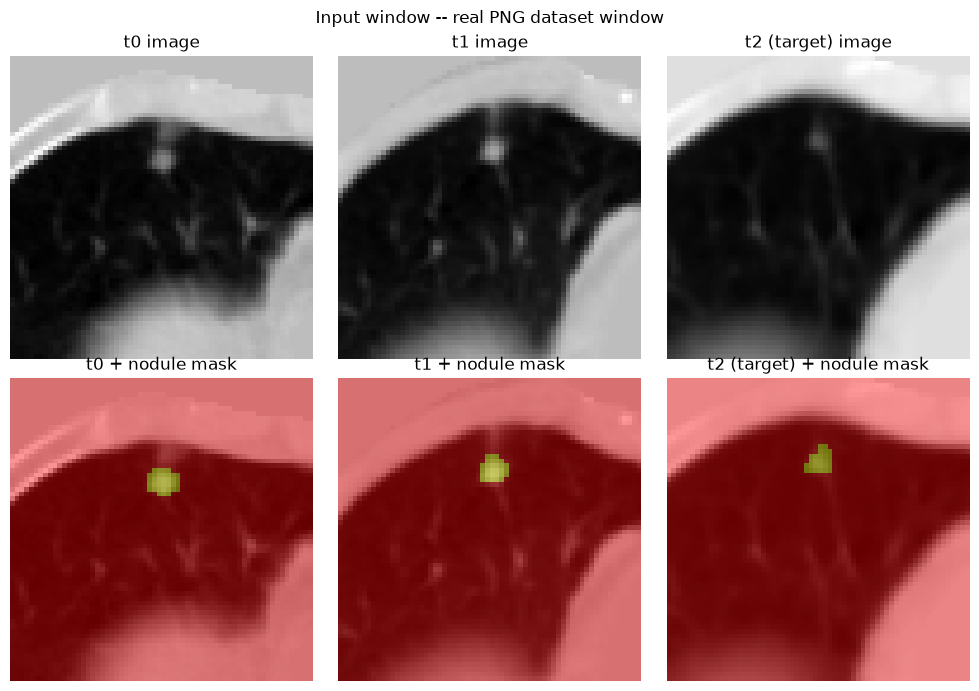

In [4]:
def mid_slice(vol):
    ''' (B,1,D,H,W) -> mid-axial 2D slice as a numpy array. '''
    return vol[0, 0, vol.shape[2] // 2].detach().cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for col, (img, mask, label) in enumerate([
    (im0, mk0, "t0"), (im1, mk1, "t1"), (im2, mk2, "t2 (target)"),
]):
    axes[0, col].imshow(mid_slice(img), cmap="gray")
    axes[0, col].set_title(f"{label} image")
    axes[0, col].axis("off")
    axes[1, col].imshow(mid_slice(img), cmap="gray")
    axes[1, col].imshow(mid_slice(mask), cmap="autumn", alpha=0.4)
    axes[1, col].set_title(f"{label} + nodule mask")
    axes[1, col].axis("off")
fig.suptitle(f"Input window -- {source}")
fig.tight_layout()
plt.show()

## 3. Forward pass: growth prediction

`NGPNet.ngpnet` returns the raw (soft) heads: predicted image, mask
logits, and deformation field. See `docs/architecture.md` and
`ngpnet/inference.py` for the inference-oriented wrapper.

In [5]:
with torch.no_grad():
    im2_pred, mk2_logits, field = model.ngpnet(im0, im1, tm0, tm1)
    mk2_pred = mk2_logits.argmax(dim=1, keepdim=True)

print("Predicted image:", tuple(im2_pred.shape))
print("Mask logits:    ", tuple(mk2_logits.shape))
print("Deformation field:", tuple(field.shape))

Predicted image: (1, 1, 64, 64, 64)
Mask logits:     (1, 2, 64, 64, 64)
Deformation field: (1, 3, 64, 64, 64)


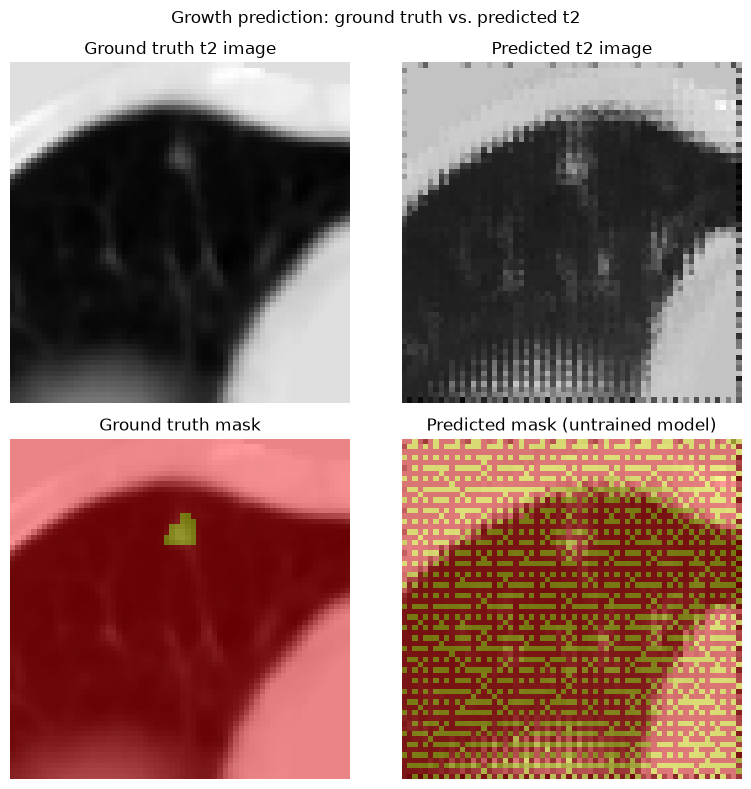

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(mid_slice(im2), cmap="gray")
axes[0, 0].set_title("Ground truth t2 image")
axes[0, 0].axis("off")

axes[0, 1].imshow(mid_slice(im2_pred), cmap="gray")
axes[0, 1].set_title("Predicted t2 image")
axes[0, 1].axis("off")

axes[1, 0].imshow(mid_slice(im2), cmap="gray")
axes[1, 0].imshow(mid_slice(mk2), cmap="autumn", alpha=0.4)
axes[1, 0].set_title("Ground truth mask")
axes[1, 0].axis("off")

axes[1, 1].imshow(mid_slice(im2_pred), cmap="gray")
axes[1, 1].imshow(mid_slice(mk2_pred), cmap="autumn", alpha=0.4)
axes[1, 1].set_title("Predicted mask (untrained model)")
axes[1, 1].axis("off")

fig.suptitle("Growth prediction: ground truth vs. predicted t2")
fig.tight_layout()
plt.show()

## 4. Metrics

The same metrics `scripts/evaluate.py` reports. **With a randomly
initialized model these numbers are meaningless as performance** -- they
only demonstrate the metrics pipeline runs correctly end-to-end. Re-run
this notebook against a trained checkpoint (load its state dict into
`model` before section 3) to get real numbers.

In [7]:
psnr = PSNRMetric(max_val=config.r_max - config.r_min)(im2_pred, im2)
ssim = SSIMMetric(max_val=config.r_max - config.r_min)(im2_pred, im2)
dice = DiceMetric(n_classes=2, ignore_bg=True)(mk2_pred, mk2)

print(f"PSNR: {psnr:.2f}")
print(f"SSIM: {ssim:.4f}")
print(f"Dice: {dice:.4f}")

PSNR: 16.85
SSIM: 0.5572
Dice: 0.0028


## 5. Deformation field

`field` warps `im1` into the predicted `im2` (see `ngpnet/heads.py:SpatialTransformer`).
Visualized here as per-voxel displacement magnitude on the same mid-axial slice.

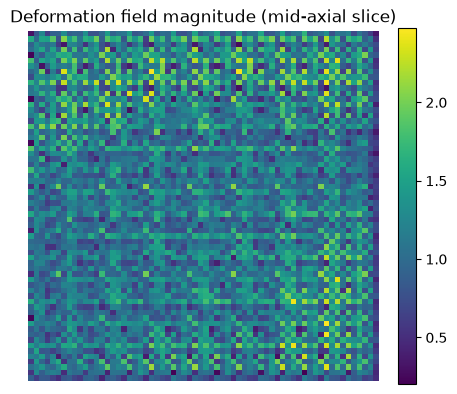

In [8]:
field_mag = torch.linalg.vector_norm(field[0], dim=0).detach().cpu().numpy()
mid = field_mag.shape[0] // 2

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(field_mag[mid], cmap="viridis")
ax.set_title("Deformation field magnitude (mid-axial slice)")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## Next steps

1. `python scripts/train.py --data-root data/external/png` to produce a real checkpoint.
2. Load it: `quality_aware_lung_ct.training.checkpoints.load_checkpoint(model, path)`,
   then re-run sections 3-5 above for real predictions and metrics.
3. `python scripts/evaluate.py --data-root data/external/png --trained-model best_model.pth`
   for full-test-set numbers (see `docs/datasets.md` for the split-overlap caveat).
4. Quality (Q), Uncertainty (U), and Fusion are unimplemented -- see
   `docs/research-status.md`.